# IMPORT LIB

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from pathlib import Path

# All paths are relative to the notebook location
BASE_DIR    = Path().resolve()
DATA_DIR    = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"


# WIND AND LOAD DATA

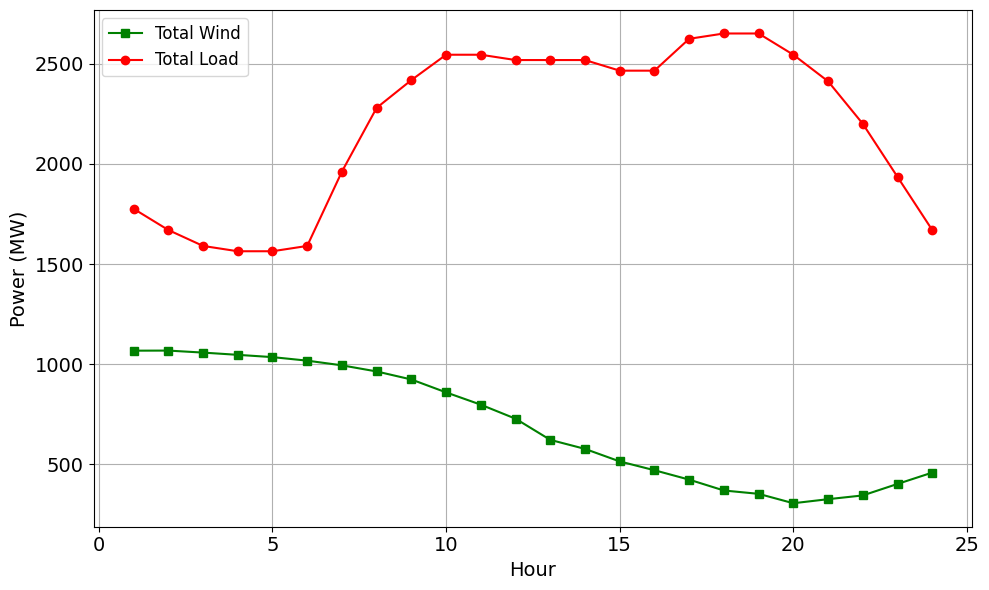

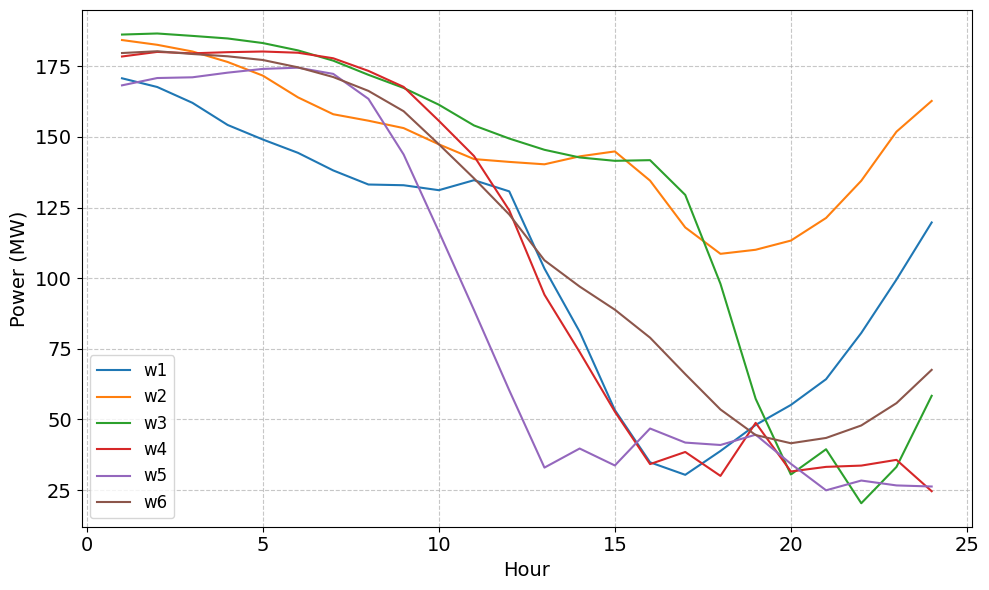

In [2]:
# ── Wind & Load input data ────────────────────────────────────────────────────
wind = pd.read_csv(DATA_DIR / "hourly_wind.csv")
load = pd.read_csv(DATA_DIR / "hourly_load.csv")

time_col      = wind.columns[0]
time_col_load = load.columns[0]
wind['TotalWind'] = wind.drop(columns=time_col).sum(axis=1)
load['TotalLoad'] = load.drop(columns=time_col_load).sum(axis=1)

# Total wind vs total load over 24 hours
plt.figure(figsize=(10, 6))
plt.plot(wind[time_col],      wind['TotalWind'], label="Total Wind", color='green', marker='s')
plt.plot(load[time_col_load], load['TotalLoad'], label="Total Load", color='red',   marker='o')
plt.xlabel("Hour", fontsize=14)
plt.ylabel("Power (MW)", fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "Wind_Load_data.pdf")
plt.show()

# Individual wind farm profiles
wind_cols = wind.drop(columns=[time_col, 'TotalWind']).columns

plt.figure(figsize=(10, 6))
for col in wind_cols:
    plt.plot(wind[time_col], wind[col], label=col)
plt.xlabel("Hour", fontsize=14)
plt.ylabel("Power (MW)", fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "Wind_individual.pdf")
plt.show()


# STEP 2

## SUpply_Demand_SOC

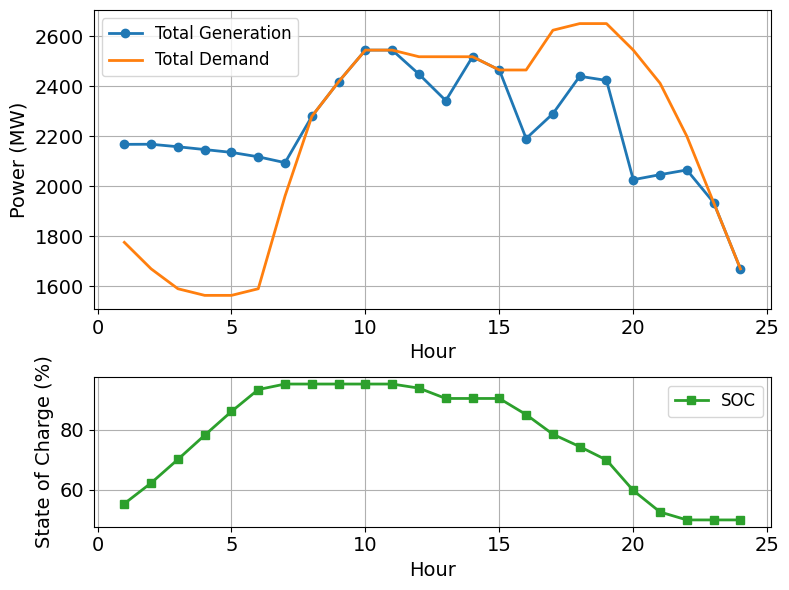

In [3]:
# ── Step 2 — System results for a single BESS scenario ───────────────────────
case        = "3000_6000"                          # change to inspect another scenario
case_folder = RESULTS_DIR / f"Step_2/With_BESS_{case}"

gen  = pd.read_csv(case_folder / "pgen_results.csv")
wind = pd.read_csv(case_folder / "pwind_results.csv")
load = pd.read_csv(case_folder / "pload_results.csv")
soc  = pd.read_csv(case_folder / "soc_results.csv")

gen_hourly   = gen.groupby("hour")["Pgen"].sum()
wind_hourly  = wind.groupby("hour")["Pwind"].sum()
load_hourly  = load.groupby("hour")["Pload"].sum()
soc_hourly   = soc.groupby("hour")["SOC"].mean() * 100  # convert to %
total_gen    = gen_hourly + wind_hourly

fig, ax = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'height_ratios': [2, 1]})

ax[0].plot(total_gen.index,   total_gen,   marker='o', color='#1f77b4', linewidth=2, label="Total Generation")
ax[0].plot(load_hourly.index, load_hourly, color='#ff7f0e', linewidth=2, label="Total Demand")
ax[0].set_xlabel("Hour", fontsize=14)
ax[0].set_ylabel("Power (MW)", fontsize=14)
ax[0].tick_params(axis='both', labelsize=14)
ax[0].grid(True)
ax[0].legend(fontsize=12)

ax[1].plot(soc_hourly.index, soc_hourly, marker='s', color='#2ca02c', linewidth=2, label="SOC")
ax[1].set_xlabel("Hour", fontsize=14)
ax[1].set_ylabel("State of Charge (%)", fontsize=14)
ax[1].tick_params(axis='both', labelsize=14)
ax[1].grid(True)
ax[1].legend(fontsize=12)

plt.tight_layout()
plt.savefig(case_folder / f"system_results_{case}.pdf")
plt.show()


## Market clearing price

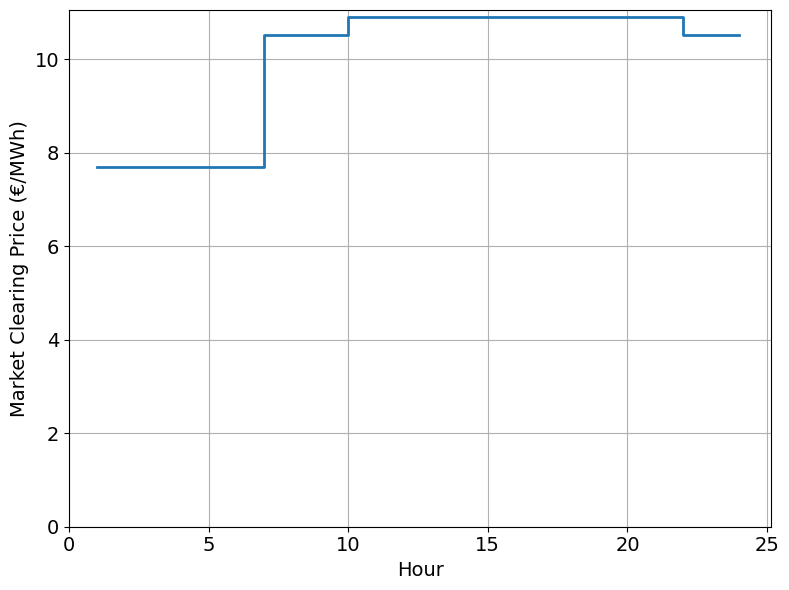

In [2]:
# ── Step 2 — MCP for a single BESS scenario ──────────────────────────────────
case        = "3000_6000"                          # change to inspect another scenario
case_folder = RESULTS_DIR / f"Step_2/With_BESS_{case}"

price = pd.read_csv(case_folder / "market_price_results.csv")

plt.figure(figsize=(8, 6))
plt.step(price['hour'], price['clearing_price'], where='pre', color='#1f77b4', linewidth=2)
plt.xlabel("Hour", fontsize=14)
plt.ylabel("Market Clearing Price (€/MWh)", fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.grid(True)
plt.ylim(bottom=0)
plt.xlim(left=0)
plt.tight_layout()
plt.savefig(case_folder / f"MCP_{case}.pdf")
plt.show()


## Sensitivity Analysis

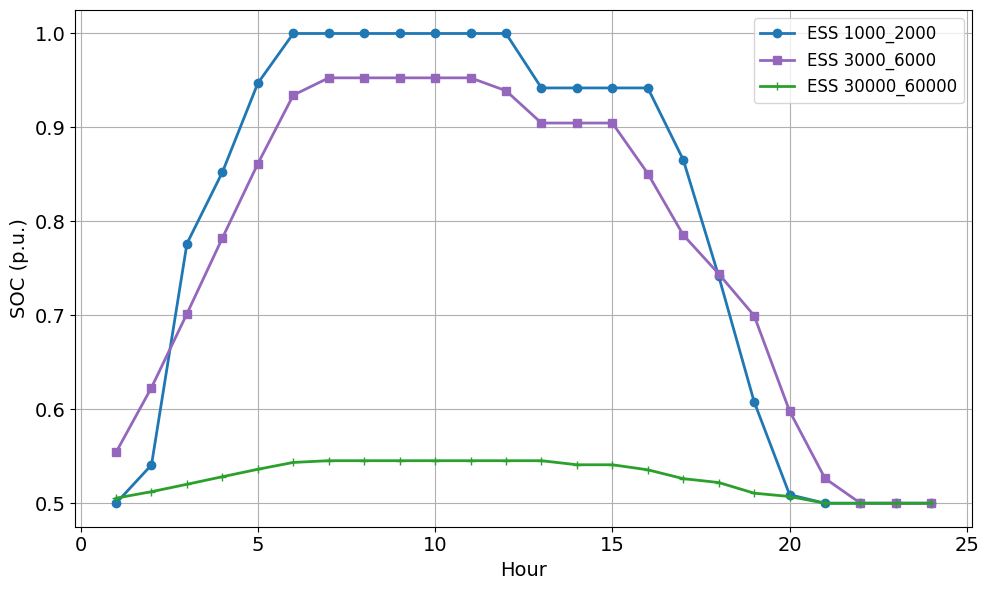

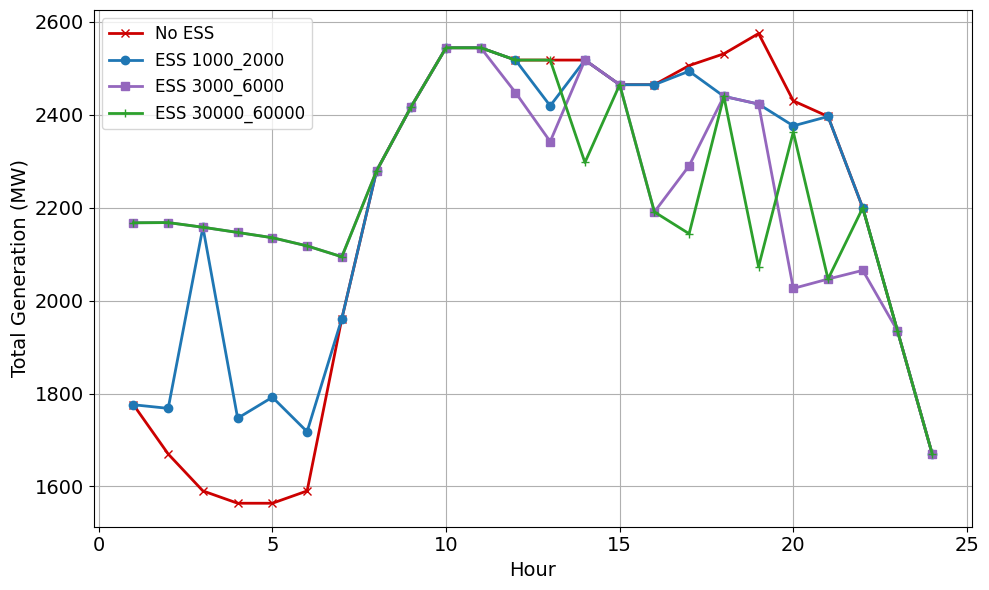

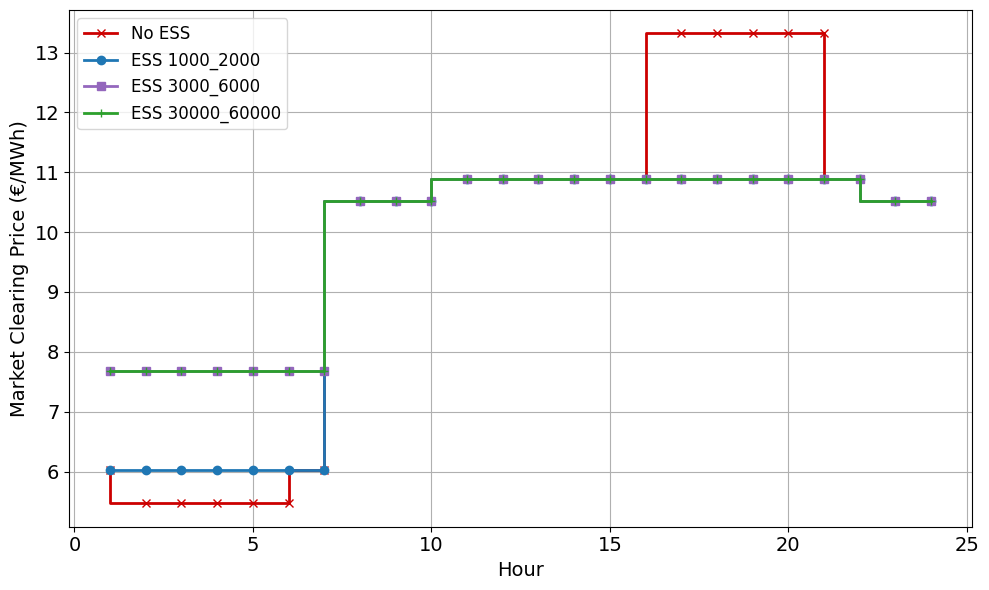

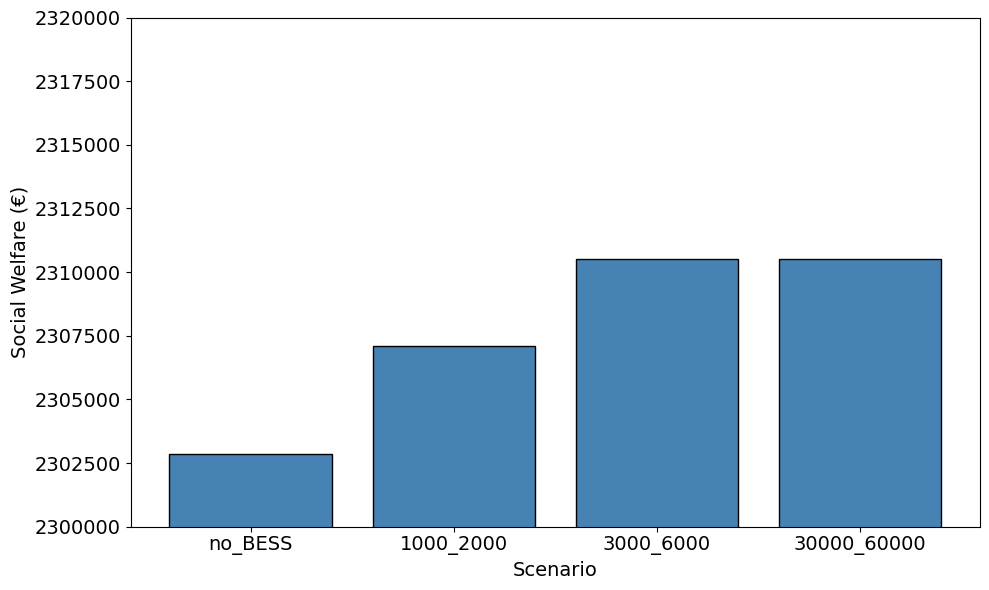

In [5]:
# ── Step 2 — Sensitivity analysis across BESS scenarios ─────────────────────
bess_cases    = ["1000_2000", "3000_6000", "30000_60000"]
no_bess_case  = "no_BESS"
folder_no_bess = RESULTS_DIR / f"Step_2/With_BESS_{no_bess_case}"

colors  = ["#1f77b4", "#9467bd", "#2ca02c", "#CC0000"]
markers = ["o", "s", "+", "x"]

# --- SOC profiles ---
plt.figure(figsize=(10, 6))
for i, case in enumerate(bess_cases):
    soc_path = RESULTS_DIR / f"Step_2/With_BESS_{case}/soc_results.csv"
    if not soc_path.exists():
        continue
    soc_df = pd.read_csv(soc_path)
    plt.plot(soc_df['hour'], soc_df['SOC'], marker=markers[i], color=colors[i], linewidth=2, label=f"ESS {case}")
plt.xlabel("Hour", fontsize=14)
plt.ylabel("SOC (p.u.)", fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "Step_2/SOC_SA.pdf")
plt.show()

# --- Total generation profiles ---
plt.figure(figsize=(10, 6))

gen_df   = pd.read_csv(folder_no_bess / "pgen_results.csv")
wind_df  = pd.read_csv(folder_no_bess / "pwind_results.csv")
total    = gen_df.groupby("hour")["Pgen"].sum() + wind_df.groupby("hour")["Pwind"].sum()
plt.plot(total.index, total.values, marker=markers[-1], color=colors[-1], linewidth=2, label="No ESS")

for i, case in enumerate(bess_cases):
    folder = RESULTS_DIR / f"Step_2/With_BESS_{case}"
    if not (folder / "pgen_results.csv").exists():
        continue
    gen_df  = pd.read_csv(folder / "pgen_results.csv")
    wind_df = pd.read_csv(folder / "pwind_results.csv")
    total   = gen_df.groupby("hour")["Pgen"].sum() + wind_df.groupby("hour")["Pwind"].sum()
    plt.plot(total.index, total.values, marker=markers[i], color=colors[i], linewidth=2, label=f"ESS {case}")

plt.xlabel("Hour", fontsize=14)
plt.ylabel("Total Generation (MW)", fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "Step_2/Generation_SA.pdf")
plt.show()

# --- MCP comparison ---
plt.figure(figsize=(10, 6))
price_no_bess = pd.read_csv(folder_no_bess / "market_price_results.csv")
plt.step(price_no_bess['hour'], price_no_bess['clearing_price'], where='pre',
         color=colors[-1], marker=markers[-1], linewidth=2, label="No ESS")

for i, case in enumerate(bess_cases):
    price_path = RESULTS_DIR / f"Step_2/With_BESS_{case}/market_price_results.csv"
    if not price_path.exists():
        continue
    price_df = pd.read_csv(price_path)
    plt.step(price_df['hour'], price_df['clearing_price'], where='pre',
             color=colors[i], marker=markers[i], linewidth=2, label=f"ESS {case}")

plt.xlabel("Hour", fontsize=14)
plt.ylabel("Market Clearing Price (€/MWh)", fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "Step_2/MCP_SA.pdf")
plt.show()

# --- Social welfare bar chart ---
all_cases = [no_bess_case] + bess_cases
values = {}
for case in all_cases:
    df = pd.read_csv(RESULTS_DIR / f"Step_2/With_BESS_{case}/social_welfare.csv")
    values[case] = df["social_welfare"].iloc[0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(values.keys(), values.values(), color="steelblue", edgecolor="black")
ax.set_xlabel("Scenario", fontsize=14)
ax.set_ylabel("Social Welfare (€)", fontsize=14)
ax.ticklabel_format(axis="y", style="plain")
ax.tick_params(axis='both', labelsize=14)
plt.ylim(2300000, 2320000)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "Step_2/SW_SA.pdf")
plt.show()


# STEP 3

## Nodal Market

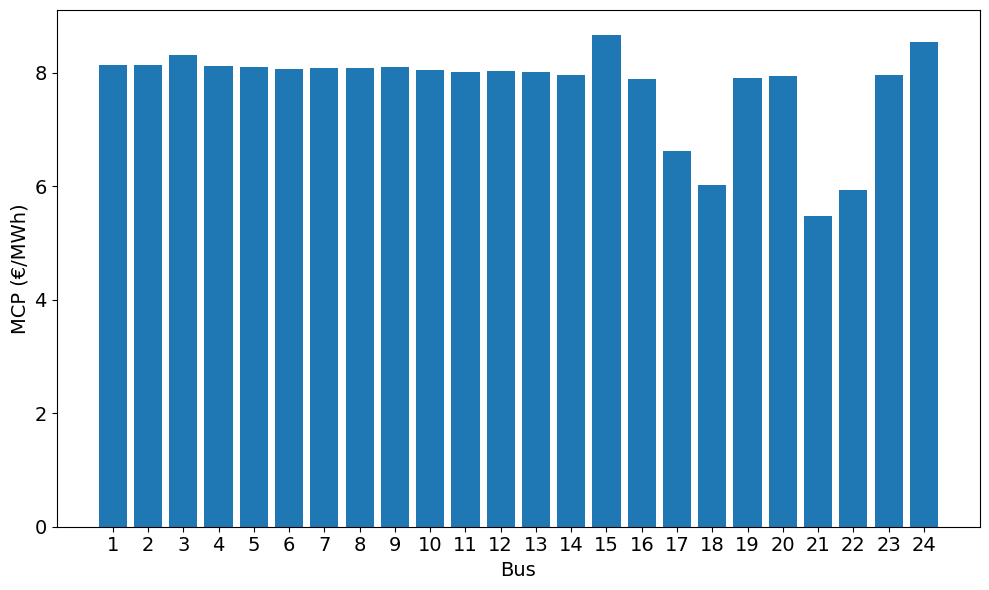

In [3]:
# ── Step 3 — Nodal MCP base case ─────────────────────────────────────────────
t           = 1                                    # hour used in Step 3
folder_path = RESULTS_DIR / f"Step_3/Nodal/t{t}/Sensitivity/line_l25_x1.00"

df = pd.read_csv(folder_path / "market_price_results.csv")
bus_labels = [b.replace("b", "") for b in df["bus"]]

plt.figure(figsize=(10, 6))
plt.bar(bus_labels, df["clearing_price"])
plt.xlabel("Bus", fontsize=14)
plt.ylabel("MCP (€/MWh)", fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"Step_3/Nodal/t{t}/Sensitivity/MCP_Nodal_Base.pdf")
plt.show()


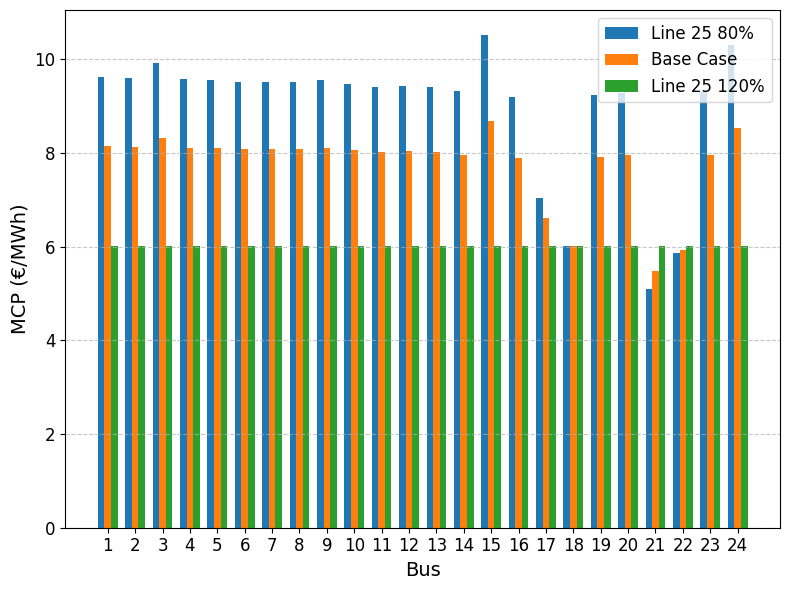

In [4]:
# ── Step 3 — Nodal MCP sensitivity analysis ──────────────────────────────────
t          = 1
line_cases = ["line_l25_x0.80", "line_l25_x1.00", "line_l25_x1.20"]
sens_dir   = RESULTS_DIR / f"Step_3/Nodal/t{t}/Sensitivity"

scenario_labels = {
    "line_l25_x0.80": "Line 25 80%",
    "line_l25_x1.00": "Base Case",
    "line_l25_x1.20": "Line 25 120%",
}

mcp_dict = {}
for case in line_cases:
    df = pd.read_csv(sens_dir / case / "market_price_results.csv")
    mcp_dict[case] = df.set_index("bus")["clearing_price"]

buses = mcp_dict[line_cases[0]].index
bus_labels = [b.replace("b", "") for b in buses]
num_cases = len(line_cases)
bar_width = 0.24
x         = np.arange(len(buses))

plt.figure(figsize=(8, 6))
for i, case in enumerate(line_cases):
    plt.bar(x + i * bar_width, mcp_dict[case], width=bar_width, label=scenario_labels[case])

plt.xlabel("Bus", fontsize=14)
plt.ylabel("MCP (€/MWh)", fontsize=14)
plt.xticks(x + bar_width * (num_cases - 1) / 2, bus_labels, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(sens_dir / "MCP_Nodal_SA.pdf")
plt.show()


# STEP 5

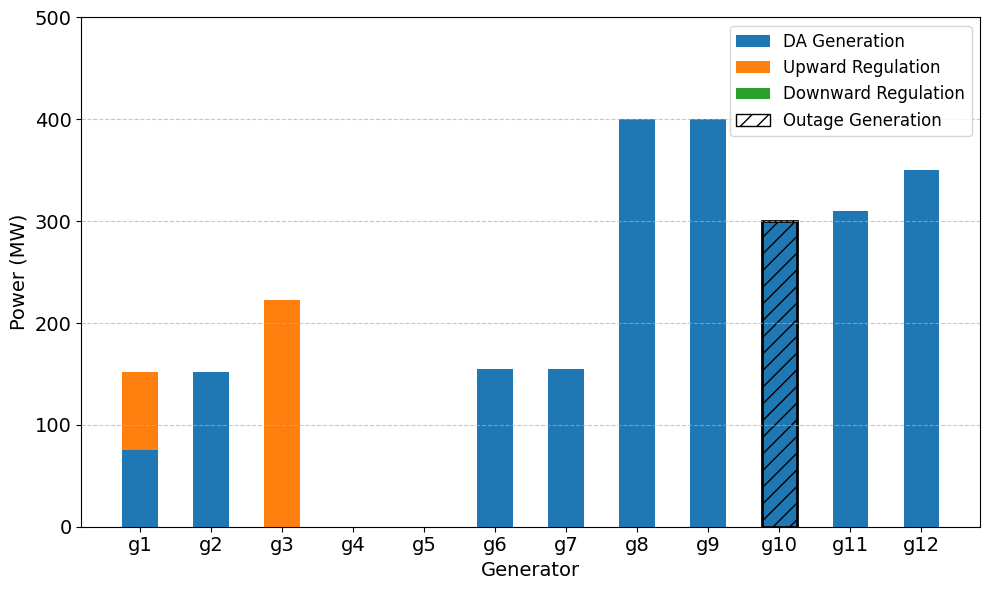

In [5]:
# ── Step 5 — Balancing market activation ─────────────────────────────────────
t           = 19
step1_folder = RESULTS_DIR / f"Step_1/t{t}"
step5_folder = RESULTS_DIR / f"Step_5/t{t}"

da_df   = pd.read_csv(step1_folder / "pgen_results.csv")
up_df   = pd.read_csv(step5_folder / "pgen_up_results.csv")
down_df = pd.read_csv(step5_folder / "pgen_down_results.csv")

gens = da_df["gen"]
DA   = da_df.set_index("gen")["Pgen"].reindex(gens).values
UP   = up_df.set_index("gen")["Pgen_up"].reindex(gens, fill_value=0).values
DOWN = down_df.set_index("gen")["Pgen_down"].reindex(gens, fill_value=0).values

failed = ["g10"]
x      = np.arange(len(gens))
width  = 0.5

plt.figure(figsize=(10, 6))
plt.bar(x, DA,    width, label="DA Generation",       color="#1f77b4")
plt.bar(x, UP,    width, bottom=DA,    label="Upward Regulation",   color="#ff7f0e")
plt.bar(x, -DOWN, width, bottom=DA+UP, label="Downward Regulation", color="#2ca02c")

for i, g in enumerate(gens):
    if g in failed:
        plt.gca().patches[i].set_edgecolor("black")
        plt.gca().patches[i].set_linewidth(2)
        plt.gca().patches[i].set_hatch("//")

outage_patch = mpatches.Patch(facecolor='none', edgecolor='black', hatch='//', label='Outage Generation')
plt.legend(handles=plt.gca().containers + [outage_patch], fontsize=12)

plt.xticks(x, gens, fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, 500)
plt.ylabel("Power (MW)", fontsize=14)
plt.xlabel("Generator", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(step5_folder / "Gen_balancing.pdf")
plt.show()


## One-price vs Two-price

## STEP 6

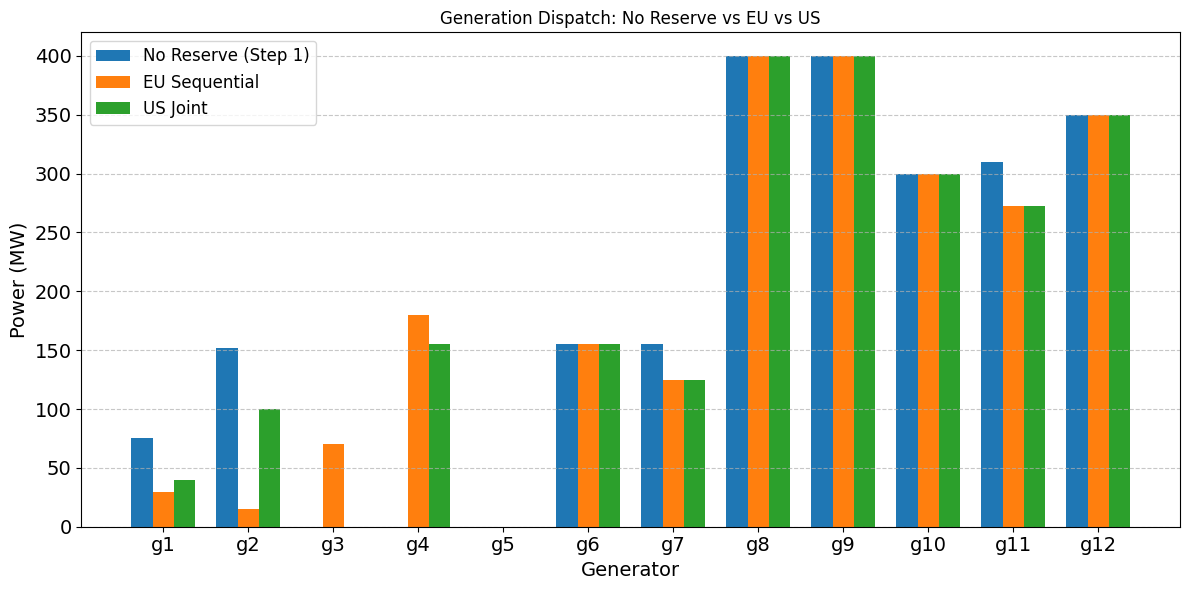

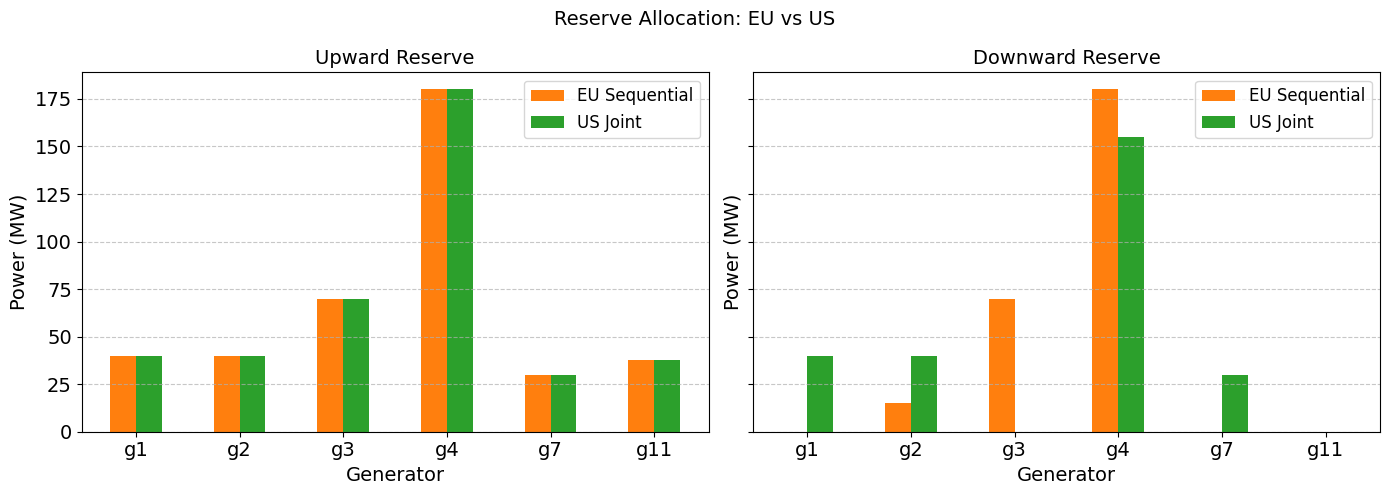

In [7]:
# ── Step 6 — Dispatch and reserve comparison: No Reserve vs EU vs US ─────────
t               = 19
step1_folder    = RESULTS_DIR / f"Step_1/t{t}"
step6_eu_folder = RESULTS_DIR / f"Step_6/EU/t{t}"
step6_us_folder = RESULTS_DIR / f"Step_6/US/t{t}"

da_df = pd.read_csv(step1_folder    / "pgen_results.csv").set_index("gen")
eu_df = pd.read_csv(step6_eu_folder / "pgen_results.csv").set_index("gen")
us_df = pd.read_csv(step6_us_folder / "pgen_results.csv").set_index("gen")

gens  = da_df.index.tolist()
x     = np.arange(len(gens))
width = 0.25

DA = da_df["Pgen"].reindex(gens).values
EU = eu_df["Pgen"].reindex(gens).values
US = us_df["Pgen"].reindex(gens).values

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, DA, width, label="No Reserve (Step 1)", color="#1f77b4")
ax.bar(x,         EU, width, label="EU Sequential",        color="#ff7f0e")
ax.bar(x + width, US, width, label="US Joint",             color="#2ca02c")

ax.set_xticks(x)
ax.set_xticklabels(gens, fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_ylabel("Power (MW)", fontsize=14)
ax.set_xlabel("Generator", fontsize=14)
ax.set_title("Generation Dispatch: No Reserve vs EU vs US")
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"Step_6/dispatch_comparison_t{t}.pdf")
plt.show()

# --- Reserve allocation: EU vs US ---
eu_res_up   = pd.read_csv(step6_eu_folder / "preserve_up_results.csv").set_index("gen")
eu_res_down = pd.read_csv(step6_eu_folder / "preserve_down_results.csv").set_index("gen")
us_res_up   = pd.read_csv(step6_us_folder / "preserve_up_results.csv").set_index("gen")
us_res_down = pd.read_csv(step6_us_folder / "preserve_down_results.csv").set_index("gen")

gen_reg = ['g1', 'g2', 'g3', 'g4', 'g7', 'g11']
xr      = np.arange(len(gen_reg))

EU_UP   = eu_res_up["P_reserve_up"].reindex(gen_reg,   fill_value=0).values
EU_DOWN = eu_res_down["P_reserve_down"].reindex(gen_reg, fill_value=0).values
US_UP   = us_res_up["P_reserve_up"].reindex(gen_reg,   fill_value=0).values
US_DOWN = us_res_down["P_reserve_down"].reindex(gen_reg, fill_value=0).values

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, eu_vals, us_vals, title in zip(
    axes,
    [EU_UP,   EU_DOWN],
    [US_UP,   US_DOWN],
    ["Upward Reserve", "Downward Reserve"]
):
    ax.bar(xr - width/2, eu_vals, width, label="EU Sequential", color="#ff7f0e")
    ax.bar(xr + width/2, us_vals, width, label="US Joint",      color="#2ca02c")
    ax.set_xticks(xr)
    ax.set_xticklabels(gen_reg, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_title(title, fontsize=14)
    ax.set_ylabel("Power (MW)", fontsize=14)
    ax.set_xlabel("Generator", fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle("Reserve Allocation: EU vs US", fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"Step_6/reserve_comparison_t{t}.pdf")
plt.show()
